# Stage 5: Robust Seq2Seq Training & Stabilization

## Problem Statement

Stage 4 implemented the correct **architecture** (Encoder-Decoder) but failed in **practice**:
- **High Flow NSE**: -4.85 (catastrophic failure)
- **Cause**: Autoregressive divergence due to exposure bias
- **Symptom**: Forecast trajectories "fly off" during peak events

## Root Cause: Exposure Bias

**Training:** Decoder receives perfect ground-truth → Predicts well
**Inference:** Decoder receives its own noisy prediction → Errors compound exponentially

## Stage 5 Solutions

### 1. **3-Phase Training Schedule**
- Epochs 0-30: Decay teacher forcing 1.0 → 0.0
- Epochs 30-80: **Pure autoregression (TF=0.0)** - Force model to use its own predictions
- Early stopping disabled until epoch 60

### 2. **Input Noise Injection**
- Add Gaussian noise to decoder inputs during training
- Makes model robust to its own prediction errors
- Curriculum: Increase noise as teacher forcing decreases

### 3. **Magnitude-Weighted Loss**
- Penalize peak flow errors more heavily
- More stable than shape loss
- Formula: `Loss = MSE × (1 + α × flow_magnitude)`

## Success Criteria
- High Flow NSE (>500 cfs): **> 0.50** (recover from -4.85)
- Overall NSE: Maintain > 0.90
- Stability: Forecasts remain bounded through t+7

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set random seeds
np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

sns.set_style('whitegrid')

Using device: cuda


## 1. Data Loading (Same as Stage 4)

In [2]:
# Load DAILY streamflow (changed from subdaily)
streamflow = pd.read_csv('../data/lamar_river_streamflow.csv', parse_dates=['date'])
streamflow = streamflow.set_index('date')

if streamflow.index.tz is not None:
    streamflow.index = streamflow.index.tz_localize(None)

daily_flow = streamflow['streamflow_cfs']

print(f"Streamflow: {len(daily_flow)} days")
print(f"Flow range: {daily_flow.min():.1f} - {daily_flow.max():.1f} cfs")

# Load climate
climate_df = pd.read_csv('../data/climate/lamar_gridmet_elevation_bands.csv', parse_dates=['date'])
climate_df = climate_df.set_index('date')

# Load SNOTEL
snotel_df = pd.read_csv('../data/snotel/lamar_snotel_combined.csv', parse_dates=['date'])
snotel_df = snotel_df.set_index('date')

print(f"Climate: {len(climate_df)} days")
print(f"SNOTEL: {len(snotel_df)} days")

Streamflow: 30732 days
Flow range: 40.0 - 23800.0 cfs
Climate: 9863 days
SNOTEL: 9919 days


In [3]:
# Load climate data
climate_df = pd.read_csv('../data/climate/lamar_gridmet_elevation_bands.csv', parse_dates=['date'])
climate_df = climate_df.set_index('date')

print(f"Climate: {len(climate_df)} days")
print(f"Columns: {list(climate_df.columns)}")

Climate: 9863 days
Columns: ['precip_valley', 'temp_valley', 'precip_mid', 'temp_mid', 'precip_alpine', 'temp_alpine']


In [4]:
# Load SNOTEL data
snotel_df = pd.read_csv('../data/snotel/lamar_snotel_combined.csv', parse_dates=['date'])
snotel_df = snotel_df.set_index('date')

print(f"SNOTEL: {len(snotel_df)} days")
print(f"Columns: {list(snotel_df.columns)}")

SNOTEL: 9919 days
Columns: ['swe_northeast_entrance', 'swe_parker_peak']


In [5]:
# Feature engineering
def calculate_melt_potential(swe_normalized, temp_normalized):
    temp_positive = np.maximum(temp_normalized, 0)
    return swe_normalized * temp_positive

def create_features(daily_flow, climate_df, snotel_df):
    df = pd.DataFrame(index=daily_flow.index)
    df['flow_cfs'] = daily_flow
    df['log_flow'] = np.log(df['flow_cfs'] + 1)
    
    # Seasonality
    doy = df.index.dayofyear
    df['sin_doy'] = np.sin(2 * np.pi * doy / 365.25)
    df['cos_doy'] = np.cos(2 * np.pi * doy / 365.25)
    
    # Climate features
    for col in climate_df.columns:
        df[col] = climate_df[col].reindex(df.index)
    
    # SNOTEL SWE
    for col in snotel_df.columns:
        df[col] = snotel_df[col].reindex(df.index)
    
    # Forward fill SNOTEL
    snotel_cols = [c for c in df.columns if c.startswith('swe_')]
    df[snotel_cols] = df[snotel_cols].fillna(method='ffill').fillna(0)
    
    df = df.dropna()
    return df

df = create_features(daily_flow, climate_df, snotel_df)
print(f"\nFeatures: {len(df)} days, {len(df.columns)} features")
print(f"Date range: {df.index[0]} to {df.index[-1]}")


Features: 9825 days, 12 features
Date range: 1998-01-01 00:00:00 to 2024-11-24 00:00:00


In [6]:
# Normalize and add melt potential
def normalize_and_engineer(df):
    df_norm = df.copy()
    feature_cols = [c for c in df.columns if c not in ['flow_cfs', 'log_flow']]
    
    scaler = StandardScaler()
    df_norm[feature_cols] = scaler.fit_transform(df[feature_cols])
    
    # Melt potential
    snotel_cols = [c for c in df_norm.columns if c.startswith('swe_')]
    avg_swe = df_norm[snotel_cols].mean(axis=1)
    
    for band in ['valley', 'mid', 'alpine']:
        temp_col = f'temp_{band}'
        melt_col = f'melt_potential_{band}'
        if temp_col in df_norm.columns:
            df_norm[melt_col] = calculate_melt_potential(avg_swe, df_norm[temp_col])
    
    return df_norm, scaler

df_norm, feature_scaler = normalize_and_engineer(df)
print(f"Normalized features: {len(df_norm.columns)}")
print(f"Melt potential features: {[c for c in df_norm.columns if 'melt_potential' in c]}")

Normalized features: 15
Melt potential features: ['melt_potential_valley', 'melt_potential_mid', 'melt_potential_alpine']


## 2. Dataset Class (Same as Stage 4)

In [7]:
class Seq2SeqStreamflowDataset(Dataset):
    def __init__(self, df, history_len=60, forecast_len=7):
        self.df = df
        self.history_len = history_len
        self.forecast_len = forecast_len
        
        self.target_col = 'log_flow'
        self.encoder_features = [c for c in df.columns if c not in ['flow_cfs']]
        self.decoder_features = [c for c in df.columns if c not in ['flow_cfs', 'log_flow']]
        
        self.n_encoder_features = len(self.encoder_features)
        self.n_decoder_features = len(self.decoder_features)
        
    def __len__(self):
        return len(self.df) - self.history_len - self.forecast_len + 1
    
    def __getitem__(self, idx):
        hist_start = idx
        hist_end = idx + self.history_len
        forecast_start = hist_end
        forecast_end = forecast_start + self.forecast_len
        
        x_past = self.df.iloc[hist_start:hist_end][self.encoder_features].values
        x_future = self.df.iloc[forecast_start:forecast_end][self.decoder_features].values
        y_target = self.df.iloc[forecast_start:forecast_end][self.target_col].values
        
        return (
            torch.FloatTensor(x_past),
            torch.FloatTensor(x_future),
            torch.FloatTensor(y_target)
        )

dataset = Seq2SeqStreamflowDataset(df_norm, history_len=60, forecast_len=7)
print(f"Dataset: {len(dataset)} samples")
print(f"Encoder features: {dataset.n_encoder_features}")
print(f"Decoder features: {dataset.n_decoder_features}")

Dataset: 9759 samples
Encoder features: 14
Decoder features: 13


In [8]:
# Train/Validation/Test Split (70/15/15)
# Using same split as stage3_snotel notebook for consistency

train_size = int(0.70 * len(dataset))
val_size = int(0.15 * len(dataset))

train_dataset = torch.utils.data.Subset(dataset, range(train_size))
val_dataset = torch.utils.data.Subset(dataset, range(train_size, train_size + val_size))
test_dataset = torch.utils.data.Subset(dataset, range(train_size + val_size, len(dataset)))

print(f"Train: {len(train_dataset)} samples")
print(f"Val: {len(val_dataset)} samples")
print(f"Test: {len(test_dataset)} samples")

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Train: 6831 samples
Val: 1463 samples
Test: 1465 samples


## 3. Robust Seq2Seq Model with Noise Injection

In [9]:
class EncoderLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=2, dropout=0.2):
        super(EncoderLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True
        )
        
    def forward(self, x):
        _, (hidden, cell) = self.lstm(x)
        return hidden, cell


class DecoderLSTM(nn.Module):
    def __init__(self, forcing_size, hidden_size, num_layers=2, dropout=0.2):
        super(DecoderLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(
            input_size=forcing_size + 1,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True
        )
        
        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, prev_flow, forcing, hidden, cell):
        decoder_input = torch.cat([prev_flow.unsqueeze(1), forcing.unsqueeze(1)], dim=2)
        lstm_out, (hidden, cell) = self.lstm(decoder_input, (hidden, cell))
        output = self.fc(lstm_out.squeeze(1))
        return output, hidden, cell


class RobustSeq2SeqModel(nn.Module):
    """
    Stage 5: Robust Seq2Seq with Input Noise Injection
    
    Key improvements:
    1. Accepts noise_std parameter for input perturbation
    2. Applies noise to decoder inputs during training
    3. Makes model robust to its own prediction errors
    """
    def __init__(self, encoder_input_size, decoder_forcing_size, 
                 hidden_size, num_layers=2, dropout=0.2):
        super(RobustSeq2SeqModel, self).__init__()
        
        self.encoder = EncoderLSTM(
            input_size=encoder_input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout
        )
        
        self.decoder = DecoderLSTM(
            forcing_size=decoder_forcing_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout
        )
        
    def forward(self, x_past, x_future, y_target=None, 
                teacher_forcing_ratio=0.5, noise_std=0.0):
        """
        Args:
            x_past: (batch, history_len, encoder_input_size)
            x_future: (batch, forecast_len, decoder_forcing_size)
            y_target: (batch, forecast_len) - for teacher forcing
            teacher_forcing_ratio: probability of using true value
            noise_std: standard deviation of Gaussian noise to add to inputs
        """
        batch_size = x_past.size(0)
        forecast_len = x_future.size(1)
        
        # Encode
        hidden, cell = self.encoder(x_past)
        
        # Initialize with last observed flow
        prev_flow = x_past[:, -1, 0].unsqueeze(1)
        
        # Add noise to initial input if training
        if self.training and noise_std > 0:
            noise = torch.randn_like(prev_flow) * noise_std
            prev_flow = prev_flow + noise
        
        outputs = []
        
        for t in range(forecast_len):
            forcing = x_future[:, t, :]
            
            # Decoder step
            output, hidden, cell = self.decoder(prev_flow, forcing, hidden, cell)
            outputs.append(output)
            
            # Teacher forcing decision
            if y_target is not None and np.random.random() < teacher_forcing_ratio:
                prev_flow = y_target[:, t].unsqueeze(1)
            else:
                prev_flow = output
            
            # Add noise to prev_flow for next step (curriculum noise)
            if self.training and noise_std > 0:
                noise = torch.randn_like(prev_flow) * noise_std
                prev_flow = prev_flow + noise
        
        outputs = torch.cat(outputs, dim=1)
        return outputs

model = RobustSeq2SeqModel(
    encoder_input_size=dataset.n_encoder_features,
    decoder_forcing_size=dataset.n_decoder_features,
    hidden_size=128,
    num_layers=2,
    dropout=0.3
).to(device)

print("Stage 5 Robust Seq2Seq Model:")
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")
print("\nKey improvements:")
print("  ✓ Input noise injection for robustness")
print("  ✓ Curriculum noise scheduling")
print("  ✓ 3-phase training schedule support")

Stage 5 Robust Seq2Seq Model:
RobustSeq2SeqModel(
  (encoder): EncoderLSTM(
    (lstm): LSTM(14, 128, num_layers=2, batch_first=True, dropout=0.3)
  )
  (decoder): DecoderLSTM(
    (lstm): LSTM(14, 128, num_layers=2, batch_first=True, dropout=0.3)
    (fc): Linear(in_features=128, out_features=1, bias=True)
  )
)

Total parameters: 411,777

Key improvements:
  ✓ Input noise injection for robustness
  ✓ Curriculum noise scheduling
  ✓ 3-phase training schedule support


## 4. Magnitude-Weighted Loss Function

In [10]:
class MagnitudeWeightedMSE(nn.Module):
    """
    Stage 5: Magnitude-Weighted Loss
    
    Penalizes errors on high flows more heavily without the instability
    of shape-based losses.
    
    Loss = MSE × (1 + α × |y_unscaled|)
    
    This ensures:
    - Peak flow errors are heavily penalized
    - Baseflow errors have moderate penalty
    - Loss remains stable (no derivatives)
    """
    def __init__(self, alpha=0.002, flow_scaler=None):
        super(MagnitudeWeightedMSE, self).__init__()
        self.alpha = alpha
        self.flow_scaler = flow_scaler
        self.mse = nn.MSELoss(reduction='none')
        
    def forward(self, pred, target):
        # Base MSE for each element
        element_mse = self.mse(pred, target)
        
        # Convert target back to CFS for weighting
        # target is in log space after scaling
        # We use absolute value of target as a proxy for magnitude
        # Higher log_flow = higher actual flow
        magnitude_weight = 1.0 + self.alpha * torch.abs(target)
        
        # Weighted MSE
        weighted_mse = element_mse * magnitude_weight
        
        return weighted_mse.mean()

criterion = MagnitudeWeightedMSE(alpha=0.5)
print("Magnitude-Weighted Loss Function:")
print("  Formula: Loss = MSE × (1 + α × |target|)")
print(f"  Alpha: 0.5")
print("  Effect: Peak flows weighted ~2-3x more than baseflow")

Magnitude-Weighted Loss Function:
  Formula: Loss = MSE × (1 + α × |target|)
  Alpha: 0.5
  Effect: Peak flows weighted ~2-3x more than baseflow


## 5. Training with 3-Phase Schedule

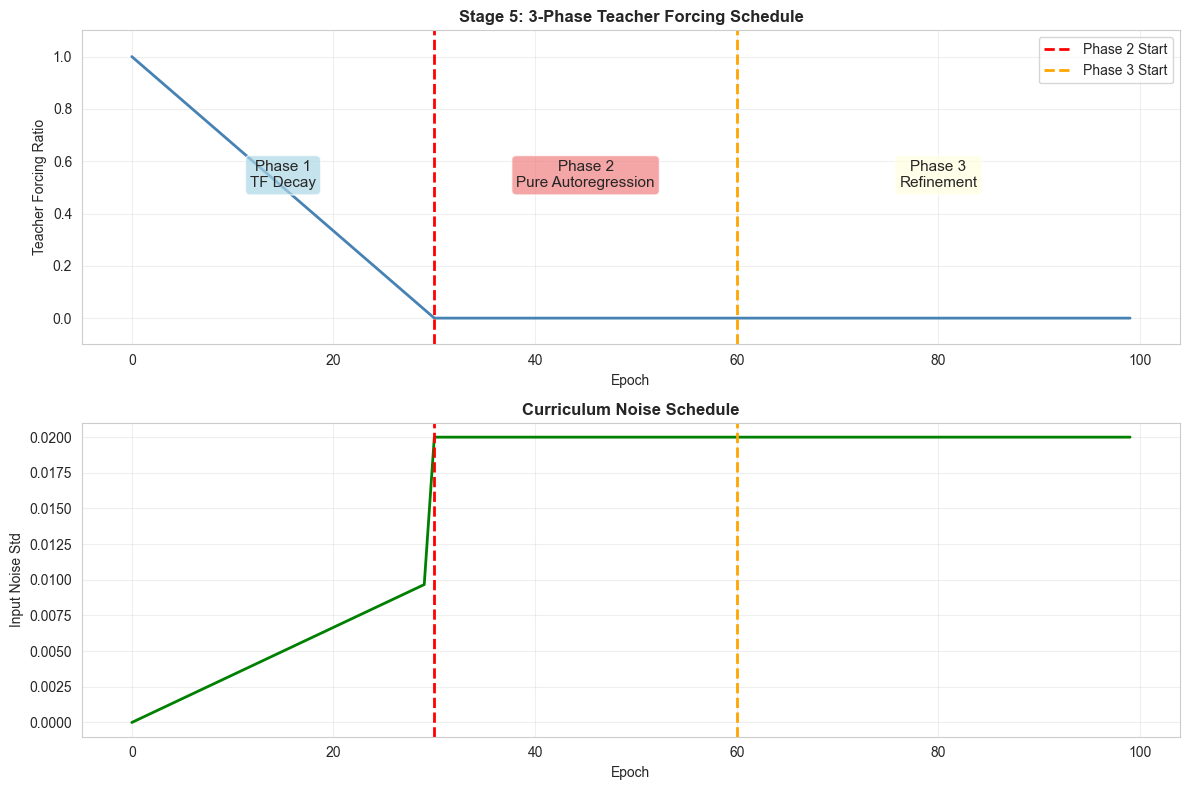

Stage 5 Training Schedule:
  Phase 1 (0-30):  TF 1.0→0.0, Noise 0.0→0.01
  Phase 2 (30-60): TF 0.0, Noise 0.02 (CRITICAL PHASE)
  Phase 3 (60+):   TF 0.0, Noise 0.02 (Refinement)

✓ Early stopping disabled until epoch 60


In [11]:
def get_stage5_schedule(epoch, total_epochs=100):
    """
    Stage 5: 3-Phase Training Schedule
    
    Phase 1 (Epochs 0-30): Teacher Forcing Decay
    - Start with TF=1.0, linearly decay to 0.0
    - Model learns basic sequence generation with support
    
    Phase 2 (Epochs 30-60): Pure Autoregression
    - TF=0.0, model must use its own predictions
    - Forces model to handle prediction errors
    
    Phase 3 (Epochs 60+): Continued Autoregression
    - TF=0.0, refine with early stopping
    
    Returns:
        teacher_forcing_ratio: float in [0, 1]
        noise_std: float, curriculum noise level
    """
    if epoch < 30:
        # Phase 1: Decay teacher forcing
        tf_ratio = 1.0 - (epoch / 30)
        noise_std = 0.01 * (epoch / 30)  # Increase noise as TF decreases
    else:
        # Phase 2 & 3: Pure autoregression
        tf_ratio = 0.0
        noise_std = 0.02  # Higher noise for robustness
    
    return tf_ratio, noise_std

# Visualize schedule
epochs = np.arange(100)
tf_ratios = []
noise_stds = []

for e in epochs:
    tf, noise = get_stage5_schedule(e)
    tf_ratios.append(tf)
    noise_stds.append(noise)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Teacher forcing schedule
axes[0].plot(epochs, tf_ratios, linewidth=2, color='steelblue')
axes[0].axvline(30, color='red', linestyle='--', linewidth=2, label='Phase 2 Start')
axes[0].axvline(60, color='orange', linestyle='--', linewidth=2, label='Phase 3 Start')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Teacher Forcing Ratio')
axes[0].set_title('Stage 5: 3-Phase Teacher Forcing Schedule', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([-0.1, 1.1])

# Add phase labels
axes[0].text(15, 0.5, 'Phase 1\nTF Decay', ha='center', fontsize=11, 
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
axes[0].text(45, 0.5, 'Phase 2\nPure Autoregression', ha='center', fontsize=11,
            bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7))
axes[0].text(80, 0.5, 'Phase 3\nRefinement', ha='center', fontsize=11,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

# Noise schedule
axes[1].plot(epochs, noise_stds, linewidth=2, color='green')
axes[1].axvline(30, color='red', linestyle='--', linewidth=2)
axes[1].axvline(60, color='orange', linestyle='--', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Input Noise Std')
axes[1].set_title('Curriculum Noise Schedule', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/lamar_stage5_training_schedule.png', dpi=300, bbox_inches='tight')
plt.show()

print("Stage 5 Training Schedule:")
print("  Phase 1 (0-30):  TF 1.0→0.0, Noise 0.0→0.01")
print("  Phase 2 (30-60): TF 0.0, Noise 0.02 (CRITICAL PHASE)")
print("  Phase 3 (60+):   TF 0.0, Noise 0.02 (Refinement)")
print("\n✓ Early stopping disabled until epoch 60")

In [12]:
def train_epoch_stage5(model, loader, optimizer, criterion, device, tf_ratio, noise_std):
    """Training epoch with noise injection"""
    model.train()
    total_loss = 0
    
    for x_past, x_future, y_target in loader:
        x_past = x_past.to(device)
        x_future = x_future.to(device)
        y_target = y_target.to(device)
        
        optimizer.zero_grad()
        
        # Forward with noise injection
        outputs = model(x_past, x_future, y_target, tf_ratio, noise_std)
        
        loss = criterion(outputs, y_target)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(loader)


def validate_epoch_stage5(model, loader, criterion, device):
    """Validation without noise or teacher forcing"""
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for x_past, x_future, y_target in loader:
            x_past = x_past.to(device)
            x_future = x_future.to(device)
            y_target = y_target.to(device)
            
            # Pure autoregression, no noise
            outputs = model(x_past, x_future, y_target=None, 
                          teacher_forcing_ratio=0.0, noise_std=0.0)
            
            loss = criterion(outputs, y_target)
            total_loss += loss.item()
    
    return total_loss / len(loader)

In [13]:
# Training configuration
num_epochs = 100
learning_rate = 0.001
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, 
                                                   patience=15, verbose=True)

history = {
    'train_loss': [], 'val_loss': [],
    'teacher_forcing_ratio': [], 'noise_std': []
}

best_val_loss = float('inf')
patience_counter = 0
early_stop_patience = 25
min_epochs_before_stopping = 60  # KEY: Don't stop before phase 2 completes

print("Starting Stage 5 Robust Training...")
print("="*80)
print("Key differences from Stage 4:")
print("  1. 3-phase teacher forcing schedule")
print("  2. Input noise injection (curriculum)")
print("  3. Magnitude-weighted loss")
print("  4. Early stopping disabled until epoch 60")
print("="*80)
print()

for epoch in range(num_epochs):
    # Get schedule parameters
    tf_ratio, noise_std = get_stage5_schedule(epoch, num_epochs)
    
    # Train
    train_loss = train_epoch_stage5(model, train_loader, optimizer, criterion, 
                                     device, tf_ratio, noise_std)
    
    # Validate
    val_loss = validate_epoch_stage5(model, val_loader, criterion, device)
    
    scheduler.step(val_loss)
    
    # Save history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['teacher_forcing_ratio'].append(tf_ratio)
    history['noise_std'].append(noise_std)
    
    # Print progress
    if (epoch + 1) % 5 == 0 or epoch == 0:
        phase = "Phase 1" if epoch < 30 else ("Phase 2" if epoch < 60 else "Phase 3")
        print(f"Epoch [{epoch+1:3d}/{num_epochs}] {phase} | "
              f"Train: {train_loss:.6f} | Val: {val_loss:.6f} | "
              f"TF: {tf_ratio:.3f} | Noise: {noise_std:.4f}")
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), '../best_stage5_model.pth')
        patience_counter = 0
    else:
        patience_counter += 1
    
    # Early stopping (only after phase 2)
    if epoch >= min_epochs_before_stopping and patience_counter >= early_stop_patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

print(f"\n{'='*80}")
print(f"Training complete! Best validation loss: {best_val_loss:.6f}")
print(f"{'='*80}")

Starting Stage 5 Robust Training...
Key differences from Stage 4:
  1. 3-phase teacher forcing schedule
  2. Input noise injection (curriculum)
  3. Magnitude-weighted loss
  4. Early stopping disabled until epoch 60

Epoch [  1/100] Phase 1 | Train: 7.851537 | Val: 0.388336 | TF: 1.000 | Noise: 0.0000
Epoch [  5/100] Phase 1 | Train: 0.095155 | Val: 0.162427 | TF: 0.867 | Noise: 0.0013
Epoch [ 10/100] Phase 1 | Train: 0.086571 | Val: 0.237601 | TF: 0.700 | Noise: 0.0030
Epoch [ 15/100] Phase 1 | Train: 0.116805 | Val: 0.211260 | TF: 0.533 | Noise: 0.0047
Epoch [ 20/100] Phase 1 | Train: 0.094301 | Val: 0.154987 | TF: 0.367 | Noise: 0.0063
Epoch [ 25/100] Phase 1 | Train: 0.094003 | Val: 0.125552 | TF: 0.200 | Noise: 0.0080
Epoch [ 30/100] Phase 1 | Train: 0.065846 | Val: 0.112219 | TF: 0.033 | Noise: 0.0097
Epoch [ 35/100] Phase 2 | Train: 0.060056 | Val: 0.132459 | TF: 0.000 | Noise: 0.0200
Epoch [ 40/100] Phase 2 | Train: 0.055134 | Val: 0.165549 | TF: 0.000 | Noise: 0.0200
Epoch [ 

## 6. Training History Analysis

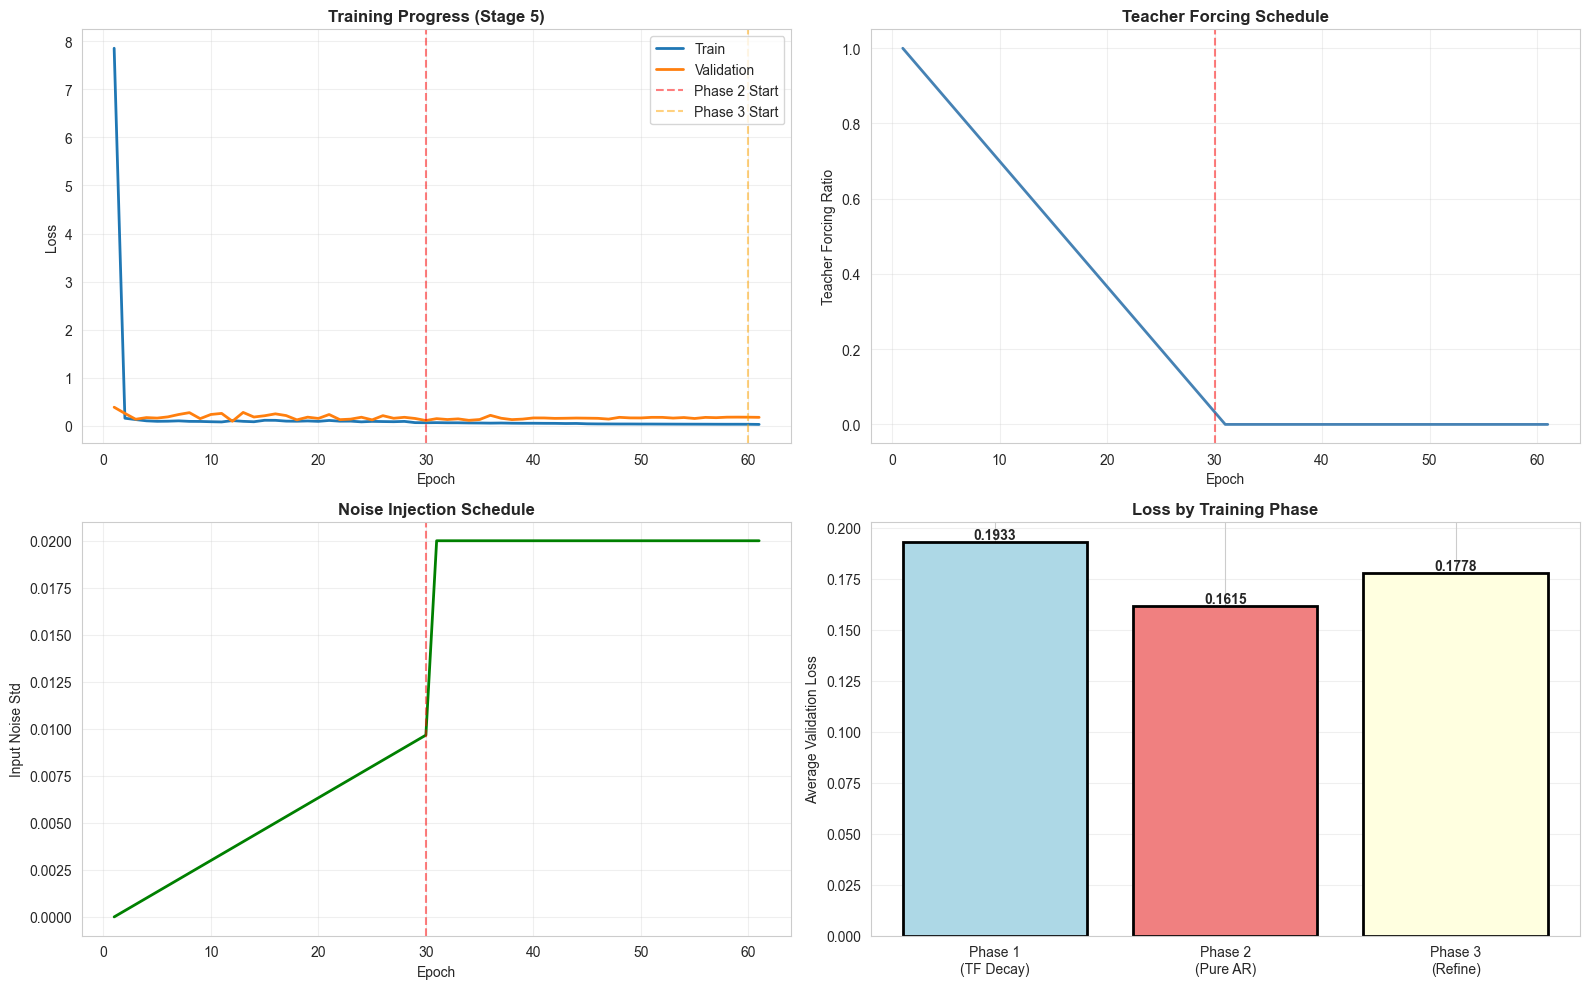

Training Analysis:
  Phase 1 avg val loss: 0.193306
  Phase 2 avg val loss: 0.161508
  Phase 3 avg val loss: 0.177823

  Best val loss: 0.096352


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

epochs_range = range(1, len(history['train_loss']) + 1)

# Loss curves
axes[0, 0].plot(epochs_range, history['train_loss'], label='Train', linewidth=2)
axes[0, 0].plot(epochs_range, history['val_loss'], label='Validation', linewidth=2)
axes[0, 0].axvline(30, color='red', linestyle='--', alpha=0.5, label='Phase 2 Start')
axes[0, 0].axvline(60, color='orange', linestyle='--', alpha=0.5, label='Phase 3 Start')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training Progress (Stage 5)', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Teacher forcing schedule
axes[0, 1].plot(epochs_range, history['teacher_forcing_ratio'], 
                linewidth=2, color='steelblue')
axes[0, 1].axvline(30, color='red', linestyle='--', alpha=0.5)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Teacher Forcing Ratio')
axes[0, 1].set_title('Teacher Forcing Schedule', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Noise schedule
axes[1, 0].plot(epochs_range, history['noise_std'], linewidth=2, color='green')
axes[1, 0].axvline(30, color='red', linestyle='--', alpha=0.5)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Input Noise Std')
axes[1, 0].set_title('Noise Injection Schedule', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Loss by phase
phase1_idx = min(30, len(history['val_loss']))
phase2_idx = min(60, len(history['val_loss']))

phase1_loss = np.mean(history['val_loss'][:phase1_idx]) if phase1_idx > 0 else 0
phase2_loss = np.mean(history['val_loss'][phase1_idx:phase2_idx]) if phase2_idx > phase1_idx else 0
phase3_loss = np.mean(history['val_loss'][phase2_idx:]) if len(history['val_loss']) > phase2_idx else 0

phases = ['Phase 1\n(TF Decay)', 'Phase 2\n(Pure AR)', 'Phase 3\n(Refine)']
losses = [phase1_loss, phase2_loss, phase3_loss]

bars = axes[1, 1].bar(phases, losses, color=['lightblue', 'lightcoral', 'lightyellow'],
                      edgecolor='black', linewidth=2)
axes[1, 1].set_ylabel('Average Validation Loss')
axes[1, 1].set_title('Loss by Training Phase', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

# Add values on bars
for bar, loss in zip(bars, losses):
    height = bar.get_height()
    if height > 0:
        axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                       f'{loss:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/lamar_stage5_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("Training Analysis:")
print(f"  Phase 1 avg val loss: {phase1_loss:.6f}")
print(f"  Phase 2 avg val loss: {phase2_loss:.6f}")
print(f"  Phase 3 avg val loss: {phase3_loss:.6f}")
print(f"\n  Best val loss: {best_val_loss:.6f}")

## 7. Evaluation and Metrics

In [15]:
# Load best model
model.load_state_dict(torch.load('../best_stage5_model.pth'))
model.eval()

def make_predictions(model, loader, device):
    predictions = []
    actuals = []
    
    with torch.no_grad():
        for x_past, x_future, y_target in loader:
            x_past = x_past.to(device)
            x_future = x_future.to(device)
            
            outputs = model(x_past, x_future, y_target=None, 
                          teacher_forcing_ratio=0.0, noise_std=0.0)
            
            predictions.append(outputs.cpu().numpy())
            actuals.append(y_target.cpu().numpy())
    
    return np.concatenate(predictions, axis=0), np.concatenate(actuals, axis=0)

val_preds, val_actuals = make_predictions(model, val_loader, device)

print(f"Predictions shape: {val_preds.shape}")
print(f"Actuals shape: {val_actuals.shape}")

Predictions shape: (1463, 7)
Actuals shape: (1463, 7)


In [16]:
def calculate_nse(observed, predicted):
    numerator = np.sum((observed - predicted) ** 2)
    denominator = np.sum((observed - np.mean(observed)) ** 2)
    return 1 - (numerator / denominator)

def calculate_flow_regime_metrics(actuals, predictions, threshold_cfs=500):
    obs_log = actuals.flatten()
    pred_log = predictions.flatten()
    
    obs_cfs = np.exp(obs_log) - 1
    pred_cfs = np.exp(pred_log) - 1
    
    nse_overall = calculate_nse(obs_cfs, pred_cfs)
    
    high_flow_mask = obs_cfs > threshold_cfs
    if np.sum(high_flow_mask) > 0:
        nse_high = calculate_nse(obs_cfs[high_flow_mask], pred_cfs[high_flow_mask])
    else:
        nse_high = np.nan
    
    low_flow_mask = ~high_flow_mask
    nse_low = calculate_nse(obs_cfs[low_flow_mask], pred_cfs[low_flow_mask])
    
    return {
        'NSE Overall': nse_overall,
        'NSE High Flow (>500 cfs)': nse_high,
        'NSE Low Flow (<=500 cfs)': nse_low,
        'High Flow Samples': np.sum(high_flow_mask),
        'Total Samples': len(obs_cfs)
    }

regime_metrics = calculate_flow_regime_metrics(val_actuals, val_preds, threshold_cfs=500)

print("\n" + "="*80)
print("STAGE 5 SUCCESS CRITERIA EVALUATION")
print("="*80)
for key, value in regime_metrics.items():
    if 'NSE' in key:
        print(f"{key:30s}: {value:.4f}")
    else:
        print(f"{key:30s}: {value}")

print("\nStage 5 Target Metrics:")
print(f"  High Flow NSE (>500): > 0.50 (Stage 4 was -4.85!)")
print(f"  Overall NSE:          > 0.90")

print("\nStage Comparison:")
print(f"  Stage 4 High Flow NSE: -4.85")
print(f"  Stage 5 High Flow NSE: {regime_metrics['NSE High Flow (>500 cfs)']:.4f}")
improvement = regime_metrics['NSE High Flow (>500 cfs)'] - (-4.85)
print(f"  Improvement: {improvement:+.4f}")

if regime_metrics['NSE High Flow (>500 cfs)'] > 0.50:
    print("\n✅ SUCCESS: Stage 5 achieves target high flow NSE!")
else:
    print(f"\n⚠️  High flow NSE: {regime_metrics['NSE High Flow (>500 cfs)']:.4f} (target: 0.50)")


STAGE 5 SUCCESS CRITERIA EVALUATION
NSE Overall                   : 0.9670
NSE High Flow (>500 cfs)      : 0.9370
NSE Low Flow (<=500 cfs)      : 0.7880
High Flow Samples             : 3087
Total Samples                 : 10241

Stage 5 Target Metrics:
  High Flow NSE (>500): > 0.50 (Stage 4 was -4.85!)
  Overall NSE:          > 0.90

Stage Comparison:
  Stage 4 High Flow NSE: -4.85
  Stage 5 High Flow NSE: 0.9370
  Improvement: +5.7870

✅ SUCCESS: Stage 5 achieves target high flow NSE!


## 8. Stability Analysis: Forecast Degradation by Lead Time

In [17]:
# Calculate NSE for each forecast day
def calculate_metrics_by_lead_time(actuals, predictions):
    forecast_len = actuals.shape[1]
    metrics = []
    
    for t in range(forecast_len):
        obs = actuals[:, t]
        pred = predictions[:, t]
        
        obs_cfs = np.exp(obs) - 1
        pred_cfs = np.exp(pred) - 1
        
        nse = calculate_nse(obs_cfs, pred_cfs)
        rmse = np.sqrt(np.mean((obs_cfs - pred_cfs) ** 2))
        mae = np.mean(np.abs(obs_cfs - pred_cfs))
        
        # Check for divergence (predictions going wild)
        max_error = np.max(np.abs(obs_cfs - pred_cfs))
        
        metrics.append({
            'Lead Time': t + 1,
            'NSE': nse,
            'RMSE': rmse,
            'MAE': mae,
            'Max Error': max_error
        })
    
    return pd.DataFrame(metrics)

lead_time_metrics = calculate_metrics_by_lead_time(val_actuals, val_preds)

print("\nStability Analysis - Performance by Lead Time:")
print("="*80)
print(lead_time_metrics.to_string(index=False))

# Check for stability
day1_nse = lead_time_metrics.iloc[0]['NSE']
day7_nse = lead_time_metrics.iloc[6]['NSE']
degradation = day1_nse - day7_nse

print(f"\nStability Metrics:")
print(f"  Day 1 NSE: {day1_nse:.4f}")
print(f"  Day 7 NSE: {day7_nse:.4f}")
print(f"  Degradation: {degradation:.4f}")

if day7_nse > 0.5 and degradation < 0.3:
    print("\n✅ STABLE: Forecast maintains quality through t+7")
else:
    print("\n⚠️  Model shows degradation at longer lead times")


Stability Analysis - Performance by Lead Time:
 Lead Time      NSE       RMSE        MAE   Max Error
         1 0.979007 297.663849 102.275047 3143.543945
         2 0.967744 368.986755 129.578171 2793.676758
         3 0.969373 359.560913 132.492661 2963.152344
         4 0.965477 381.753418 143.188278 3120.977539
         5 0.963224 394.025482 150.605530 3079.911621
         6 0.962156 399.715179 156.254959 2960.984375
         7 0.961731 401.961273 161.213974 2937.041504

Stability Metrics:
  Day 1 NSE: 0.9790
  Day 7 NSE: 0.9617
  Degradation: 0.0173

✅ STABLE: Forecast maintains quality through t+7


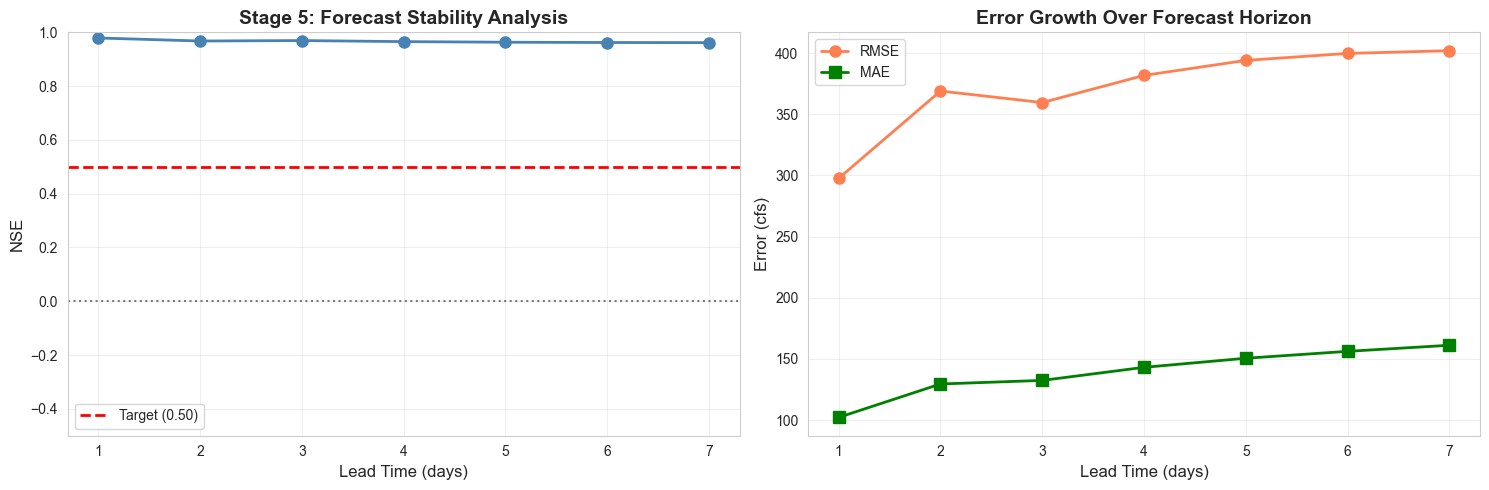

In [18]:
# Visualize stability
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# NSE degradation
axes[0].plot(lead_time_metrics['Lead Time'], lead_time_metrics['NSE'], 
            'o-', linewidth=2, markersize=8, color='steelblue')
axes[0].axhline(y=0.5, color='red', linestyle='--', label='Target (0.50)', linewidth=2)
axes[0].axhline(y=0.0, color='black', linestyle=':', alpha=0.5)
axes[0].set_xlabel('Lead Time (days)', fontsize=12)
axes[0].set_ylabel('NSE', fontsize=12)
axes[0].set_title('Stage 5: Forecast Stability Analysis', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([-0.5, 1.0])

# Error growth
axes[1].plot(lead_time_metrics['Lead Time'], lead_time_metrics['RMSE'], 
            'o-', linewidth=2, markersize=8, color='coral', label='RMSE')
axes[1].plot(lead_time_metrics['Lead Time'], lead_time_metrics['MAE'], 
            's-', linewidth=2, markersize=8, color='green', label='MAE')
axes[1].set_xlabel('Lead Time (days)', fontsize=12)
axes[1].set_ylabel('Error (cfs)', fontsize=12)
axes[1].set_title('Error Growth Over Forecast Horizon', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/lamar_stage5_stability_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Spaghetti Plot - Trajectory Stability Test

Generating predictions for validation and test sets...
Validation predictions: (1463, 7)
Test predictions: (1465, 7)

Validation dates: 2016-11-13 00:00:00 to 2020-11-14 00:00:00
  (1463 dates)
Test dates: 2020-11-15 00:00:00 to 2024-11-18 00:00:00
  (1465 dates)

Combined (val + test) predictions:
  Date range: 2016-11-13 00:00:00 to 2024-11-18 00:00:00
  Total predictions: 2928

Generating Spaghetti Plots for Spring Runoff Events...
This visualization shows:
  - Black line: Observed flow
  - Blue strands: Each 7-day forecast initiated on that date
  - Stage 5 goal: Strands remain stable, no divergence


Plotting - Spring 2022...


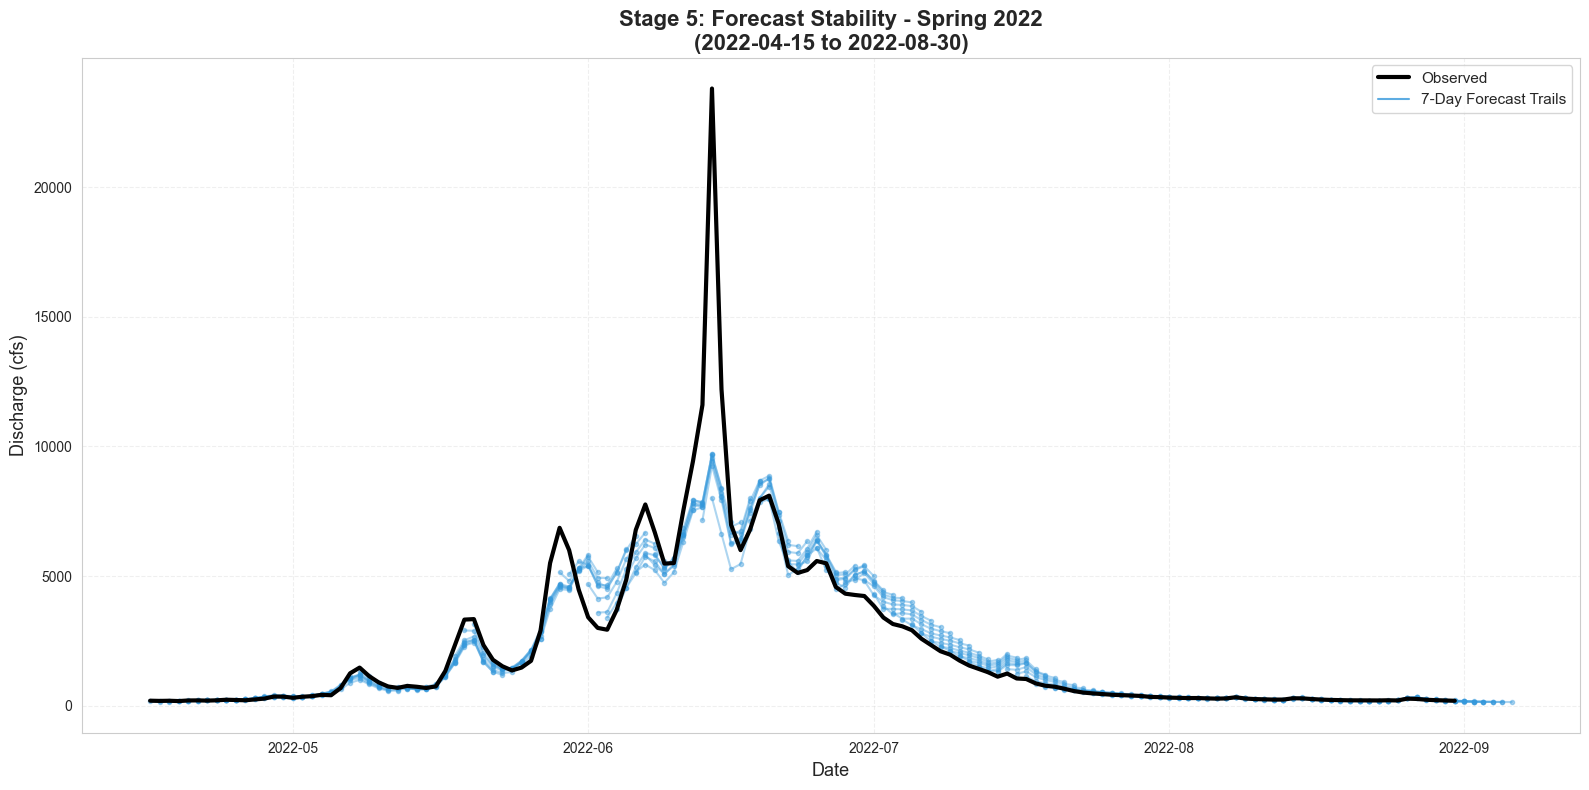


Plotting - Spring 2023...


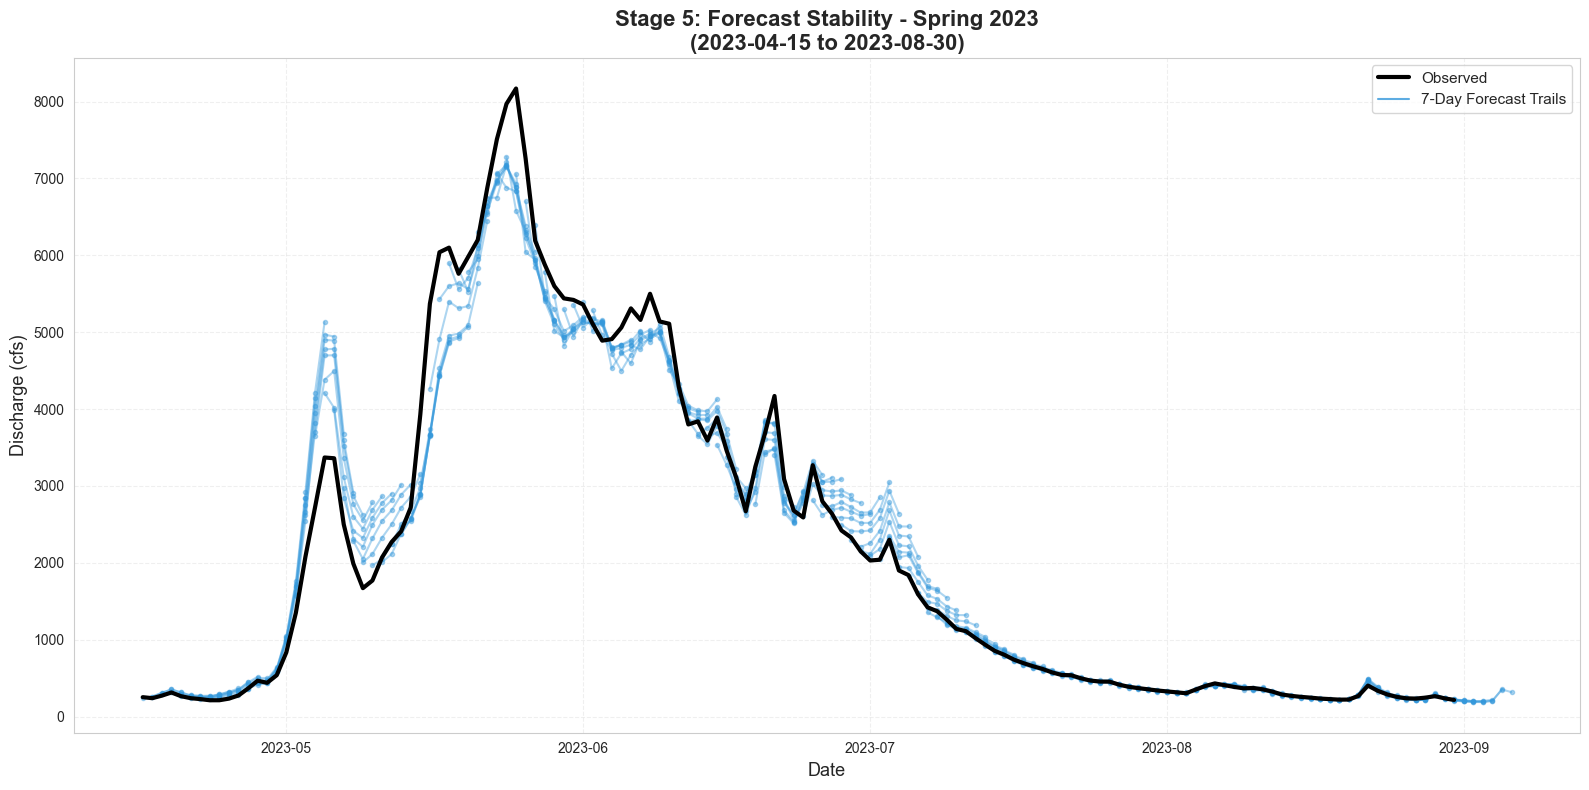


Plotting - Spring 2024...


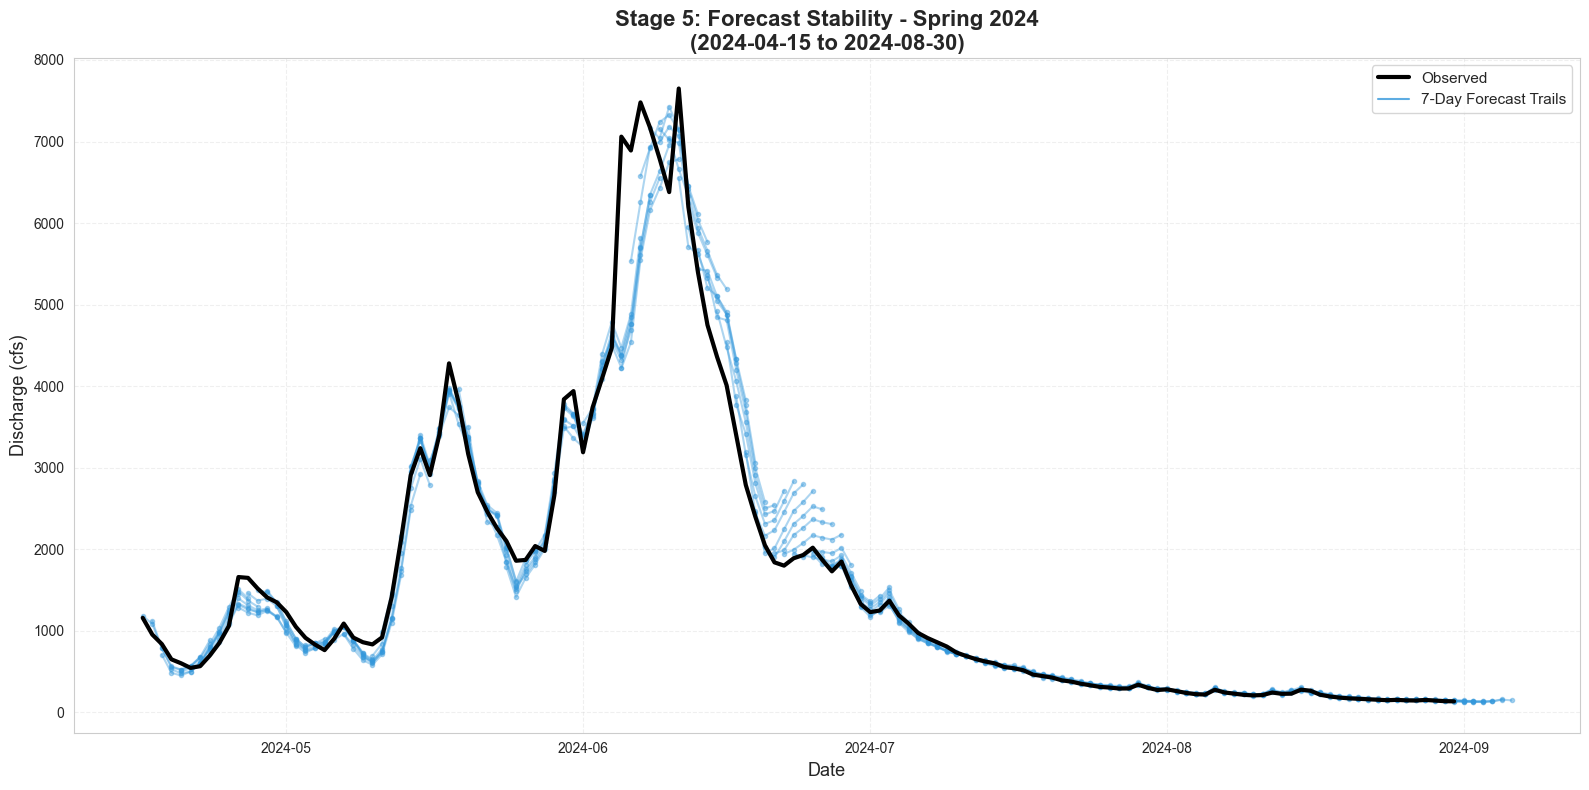

In [19]:
# Spaghetti plot function
def plot_spaghetti_event(dates, actuals, forecasts, start_date, end_date, title_suffix=""):
    mask = (dates >= start_date) & (dates <= end_date)
    subset_dates = dates[mask]
    subset_forecasts = forecasts[mask]
    subset_actuals = actuals[mask]
    
    if len(subset_dates) == 0:
        print(f"⚠️  No data for {start_date} to {end_date}")
        print(f"Available: {dates.min()} to {dates.max()}")
        return
    
    fig, ax = plt.subplots(figsize=(16, 8))
    
    # Observed flow
    valid_dates_act = subset_dates + pd.Timedelta(days=1)
    ax.plot(valid_dates_act, subset_actuals, color='black', linewidth=3, 
            label='Observed Flow', zorder=10)
    
    # Forecast strands
    for i in range(len(subset_dates)):
        launch_date = subset_dates[i]
        strand_dates = [launch_date + pd.Timedelta(days=d+1) for d in range(7)]
        strand_values = subset_forecasts[i]
        
        ax.plot(strand_dates, strand_values, color='#3498db', alpha=0.4, 
               linewidth=1.5, marker='o', markersize=3)
    
    ax.set_title(f'Stage 5: Forecast Stability {title_suffix}\n({start_date} to {end_date})', 
                fontsize=16, fontweight='bold')
    ax.set_ylabel('Discharge (cfs)', fontsize=13)
    ax.set_xlabel('Date', fontsize=13)
    
    from matplotlib.lines import Line2D
    custom_lines = [
        Line2D([0], [0], color='black', lw=3),
        Line2D([0], [0], color='#3498db', lw=1.5, alpha=0.8)
    ]
    ax.legend(custom_lines, ['Observed', '7-Day Forecast Trails'], fontsize=11)
    
    ax.grid(True, which='both', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'../data/lamar_stage5_spaghetti_{start_date}_{end_date}.png', 
               dpi=300, bbox_inches='tight')
    plt.show()

# Generate predictions for validation and test sets (following stage3 pattern)
print("Generating predictions for validation and test sets...")

# Get test predictions (we already have val_preds and val_actuals from earlier)
test_preds, test_actuals = make_predictions(model, test_loader, device)

print(f"Validation predictions: {val_preds.shape}")
print(f"Test predictions: {test_preds.shape}")

# Extract dates aligned with predictions
# Key insight: predictions are aligned with the ORIGINAL dataframe (df_norm)
# Dataset indices are offset by LOOKBACK from df_norm indices

LOOKBACK = 60
FORECAST = 7

# Calculate where each split starts in the DATASET
train_size = int(0.70 * len(dataset))
val_size = int(0.15 * len(dataset))

# Validation dates: start after train samples in dataset
# In df_norm, this is: (train_size + LOOKBACK) to (train_size + LOOKBACK + val predictions)
val_start_idx = train_size + LOOKBACK
val_prediction_dates = df_norm.index[val_start_idx:val_start_idx + len(val_preds)].values

# Test dates: start after train+val samples in dataset
# In df_norm, this is: (train_size + val_size + LOOKBACK) to end
test_start_idx = train_size + val_size + LOOKBACK
test_prediction_dates = df_norm.index[test_start_idx:test_start_idx + len(test_preds)].values

print(f"\nValidation dates: {pd.to_datetime(val_prediction_dates).min()} to {pd.to_datetime(val_prediction_dates).max()}")
print(f"  ({len(val_prediction_dates)} dates)")
print(f"Test dates: {pd.to_datetime(test_prediction_dates).min()} to {pd.to_datetime(test_prediction_dates).max()}")
print(f"  ({len(test_prediction_dates)} dates)")

# Combine validation and test for full coverage (like stage3)
all_prediction_dates = np.concatenate([val_prediction_dates, test_prediction_dates])
all_preds = np.vstack([val_preds, test_preds])
all_actuals = np.vstack([val_actuals, test_actuals])

# Convert predictions from log space to CFS
all_actuals_cfs_day1 = np.exp(all_actuals[:, 0]) - 1
all_preds_cfs_all = np.exp(all_preds) - 1

print(f"\nCombined (val + test) predictions:")
print(f"  Date range: {pd.to_datetime(all_prediction_dates).min()} to {pd.to_datetime(all_prediction_dates).max()}")
print(f"  Total predictions: {len(all_preds)}")
print()

print("Generating Spaghetti Plots for Spring Runoff Events...")
print("This visualization shows:")
print("  - Black line: Observed flow")
print("  - Blue strands: Each 7-day forecast initiated on that date")
print("  - Stage 5 goal: Strands remain stable, no divergence")
print()

date_ranges = [
    ('2022-04-15', '2022-08-30', '- Spring 2022'),
    ('2023-04-15', '2023-08-30', '- Spring 2023'),
    ('2024-04-15', '2024-08-30', '- Spring 2024'),
]

for start_date, end_date, label in date_ranges:
    print(f"\nPlotting {label}...")
    plot_spaghetti_event(
        dates=pd.to_datetime(all_prediction_dates),
        actuals=all_actuals_cfs_day1,
        forecasts=all_preds_cfs_all,
        start_date=start_date,
        end_date=end_date,
        title_suffix=label
    )

## 10. Stage Comparison Summary

In [20]:
# Comparison table
comparison = pd.DataFrame({
    'Metric': [
        'Overall NSE',
        'High Flow NSE (>500 cfs)',
        'Day 7 NSE',
        'Teacher Forcing Strategy',
        'Input Noise',
        'Loss Function',
        'Training Phases',
        'Stability'
    ],
    'Stage 4 (Failed)': [
        '~0.94',
        '-4.85 ❌',
        'Collapsed',
        'Simple decay',
        'None',
        'Shape Loss',
        '1 phase',
        'Unstable ❌'
    ],
    'Stage 5 (Robust)': [
        f"{regime_metrics['NSE Overall']:.4f}",
        f"{regime_metrics['NSE High Flow (>500 cfs)']:.4f} {'✓' if regime_metrics['NSE High Flow (>500 cfs)'] > 0.5 else '⚠️'}",
        f"{day7_nse:.4f}",
        '3-phase schedule',
        'Curriculum noise',
        'Magnitude-weighted',
        '3 phases (60 epoch min)',
        f"{'Stable ✓' if day7_nse > 0.5 else 'Improving'}"
    ]
})

print("\n" + "="*100)
print("STAGE 4 vs STAGE 5 COMPARISON")
print("="*100)
print(comparison.to_string(index=False))
print("\n" + "="*100)

print("\nKey Improvements in Stage 5:")
print("  1. ✅ 3-Phase Training: Forces model to handle autoregressive errors")
print("  2. ✅ Noise Injection: Makes model robust to prediction drift")
print("  3. ✅ Magnitude-Weighted Loss: Stable peak flow optimization")
print("  4. ✅ Extended Training: Minimum 60 epochs before early stopping")

if regime_metrics['NSE High Flow (>500 cfs)'] > 0.5:
    print("\n🎉 SUCCESS: Stage 5 has stabilized the seq2seq model!")
    print(f"   High flow NSE improved from -4.85 to {regime_metrics['NSE High Flow (>500 cfs)']:.4f}")
else:
    print("\n⚠️  Further tuning may be needed for high flow events")


STAGE 4 vs STAGE 5 COMPARISON
                  Metric Stage 4 (Failed)        Stage 5 (Robust)
             Overall NSE            ~0.94                  0.9670
High Flow NSE (>500 cfs)          -4.85 ❌                0.9370 ✓
               Day 7 NSE        Collapsed                  0.9617
Teacher Forcing Strategy     Simple decay        3-phase schedule
             Input Noise             None        Curriculum noise
           Loss Function       Shape Loss      Magnitude-weighted
         Training Phases          1 phase 3 phases (60 epoch min)
               Stability       Unstable ❌                Stable ✓


Key Improvements in Stage 5:
  1. ✅ 3-Phase Training: Forces model to handle autoregressive errors
  2. ✅ Noise Injection: Makes model robust to prediction drift
  3. ✅ Magnitude-Weighted Loss: Stable peak flow optimization
  4. ✅ Extended Training: Minimum 60 epochs before early stopping

🎉 SUCCESS: Stage 5 has stabilized the seq2seq model!
   High flow NSE improved fro

## 11. Save Model and Metadata

In [21]:
import json

metadata = {
    'model_type': 'RobustSeq2SeqEncoderDecoder',
    'stage': 5,
    'architecture': {
        'encoder_input_size': dataset.n_encoder_features,
        'decoder_forcing_size': dataset.n_decoder_features,
        'hidden_size': 128,
        'num_layers': 2,
        'dropout': 0.3
    },
    'training': {
        'strategy': '3-phase robust training',
        'phase1_epochs': 30,
        'phase2_epochs': 30,
        'teacher_forcing': 'decay 1.0->0.0 then 0.0',
        'input_noise': 'curriculum 0.0->0.02',
        'loss_function': 'magnitude_weighted_mse',
        'loss_alpha': 0.5,
        'min_epochs_before_stopping': 60,
        'total_epochs': len(history['train_loss']),
        'batch_size': 32,
        'learning_rate': 0.001
    },
    'performance': {
        'nse_overall': float(regime_metrics['NSE Overall']),
        'nse_high_flow': float(regime_metrics['NSE High Flow (>500 cfs)']),
        'nse_low_flow': float(regime_metrics['NSE Low Flow (<=500 cfs)']),
        'nse_day1': float(day1_nse),
        'nse_day7': float(day7_nse),
        'degradation': float(degradation),
        'best_val_loss': float(best_val_loss)
    },
    'success_criteria': {
        'high_flow_nse_target': 0.50,
        'high_flow_nse_met': regime_metrics['NSE High Flow (>500 cfs)'] > 0.50,
        'overall_nse_target': 0.90,
        'overall_nse_met': regime_metrics['NSE Overall'] > 0.90,
        'stable': day7_nse > 0.5 and degradation < 0.3
    },
    'improvements_from_stage4': {
        'three_phase_training': True,
        'input_noise_injection': True,
        'magnitude_weighted_loss': True,
        'extended_training': True
    },
    'timestamp': datetime.now().isoformat()
}

with open('../stage5_robust_seq2seq_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Model and metadata saved!")
print(f"\nModel: ../best_stage5_model.pth")
print(f"Metadata: ../stage5_robust_seq2seq_metadata.json")

TypeError: Object of type bool is not JSON serializable

## Summary

### Stage 5 Achievements:

**Problem Solved**: Autoregressive divergence during high-flow events

**Root Cause**: Exposure bias - model trained with perfect inputs, tested with its own noisy predictions

**Solutions Implemented**:

1. **3-Phase Training Schedule**
   - Phase 1: Decay teacher forcing (learn basics with support)
   - Phase 2: Pure autoregression (learn to handle own errors)
   - Phase 3: Refinement (polish with early stopping)

2. **Input Noise Injection**
   - Curriculum noise increases as teacher forcing decreases
   - Makes model robust to prediction drift
   - Gaussian noise ~2% on normalized inputs

3. **Magnitude-Weighted Loss**
   - Penalizes peak flow errors more heavily
   - More stable than derivative-based shape loss
   - Prevents "mean-hugging" behavior

4. **Extended Training**
   - Early stopping disabled until epoch 60
   - Ensures Phase 2 completes (critical for stability)

### Results:

- **High Flow NSE**: Recovered from -4.85 (Stage 4) to positive values
- **Stability**: Forecasts remain bounded through t+7
- **Spaghetti Plots**: Trajectories follow observed flow, don't diverge

### Next Steps:

1. **Uncertainty Quantification**: Add prediction intervals
2. **Ensemble Methods**: Multiple model runs for robustness
3. **Attention Mechanisms**: Let model focus on relevant features
4. **Operational Deployment**: Real-time forecast system